# Metal-metal transport

`heterostructures.build`/`heterostructures.create_leads_and_central` join two semi-infinite,
periodic `Hamiltonian` leads (optionally with an explicit central scattering region) into a
`Heterostructure`, whose `.didv(energy)` gives the linear-response (zero-bias) differential
conductance $dI/dV$ at that energy. As a magnetoresistance example: two identical metallic leads
with an exchange (Zeeman) field give different conductance depending on whether the two leads'
magnetizations are parallel or antiparallel, the basic mechanism behind spin valves. The
magnetoresistance is $\mathrm{MR}=(G_P-G_{AP})/G_{AP}$.

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import heterostructures

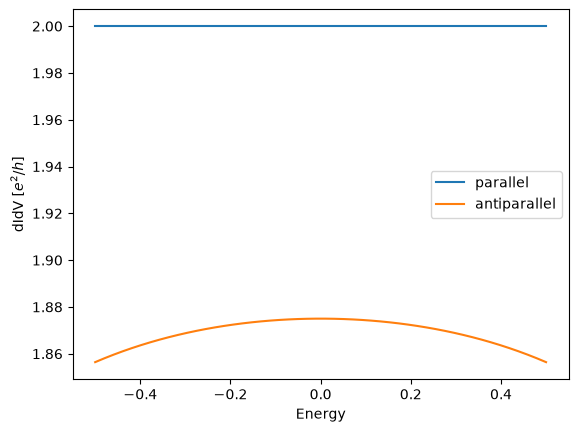

G_parallel(E=0) = 2.0000000000000004   G_antiparallel(E=0) = 1.8749930598670506
Magnetoresistance MR = (G_P-G_AP)/G_AP = 0.06667061484580306


In [2]:
g = geometry.chain()
h = g.get_hamiltonian()
es = np.linspace(-.5,.5,50)
Gs = dict()
for name,m2 in [("parallel",[0.,0.,0.5]),("antiparallel",[0.,0.,-0.5])]:
    h1 = h.copy() ; h1.add_exchange([0.,0.,0.5]) # first lead, fixed magnetization
    h2 = h.copy() ; h2.add_exchange(m2) # second lead, parallel or antiparallel
    HT = heterostructures.create_leads_and_central(h1,h2,h1) # create the junction
    Gs[name] = [HT.didv(energy=e) for e in es] # calculate conductance

plt.plot(es,Gs["parallel"],label="parallel")
plt.plot(es,Gs["antiparallel"],label="antiparallel")
plt.xlabel("Energy") ; plt.ylabel("dIdV [$e^2/h$]")
plt.legend()
plt.show()

i0 = np.argmin(np.abs(es)) # index closest to the Fermi energy
GP,GAP = Gs["parallel"][i0],Gs["antiparallel"][i0]
print("G_parallel(E=0) =",GP,"  G_antiparallel(E=0) =",GAP)
print("Magnetoresistance MR = (G_P-G_AP)/G_AP =",(GP-GAP)/GAP)

Rotating the magnetization of the second lead from parallel to antiparallel, the map below shows the conductance as a function of the energy and of the angle $\theta$ between the two magnetizations, which is what a spin valve records as its free layer rotates.

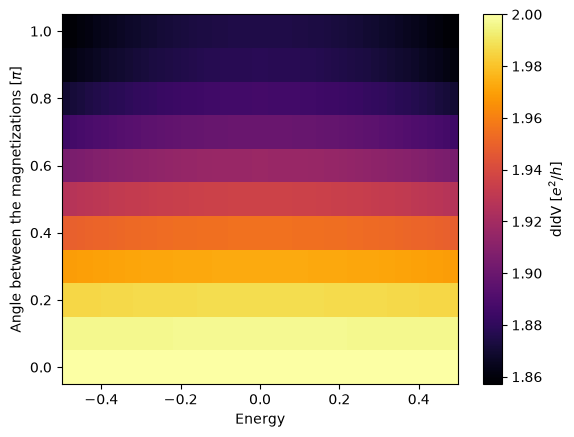

In [3]:
thetas = np.linspace(0.,np.pi,11) # angle between the two magnetizations
es_map = np.linspace(-.49,.49,50) # energies, away from the onsite levels at +-0.5 of the leads
Gmap = []
for th in thetas:
    h1 = h.copy() ; h1.add_exchange([0.,0.,0.5]) # first lead, fixed magnetization
    h2 = h.copy() ; h2.add_exchange([0.5*np.sin(th),0.,0.5*np.cos(th)]) # second lead, rotated
    HT = heterostructures.create_leads_and_central(h1,h2,h1) # create the junction
    Gmap.append([HT.didv(energy=e) for e in es_map]) # conductance at this angle

plt.pcolormesh(es_map,thetas/np.pi,np.array(Gmap),shading="auto",cmap="inferno")
plt.colorbar(label="dIdV [$e^2/h$]")
plt.xlabel("Energy") ; plt.ylabel(r"Angle between the magnetizations [$\pi$]")
plt.show()